In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

%matplotlib inline

In [3]:
df = pd.read_csv("cleaned_brain_tumor.csv")


In [4]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (36, 7466)


In [5]:
df.head()

,Unnamed: 0,X53416,M83670,X90908,M97496,X90908.1,U37019,R48602,T96548,X64559,...,H87456,R64130,H11125.1,U22055,L22524,M13699.1,X54489,T55008,M10065.2,y
0,0,70,-81,25,10,22,113,36,163,9,...,75,5,68,138,53,-4,123,2,19,tumor
1,1,108,-30,-7,60,0,24,8,113,-3,...,186,6,60,93,140,-3,271,-1,-51,tumor
2,2,75,-1,5,48,6,34,27,35,-1,...,186,225,94,62,39,-14,127,7,192,tumor
3,3,871,4,14,78,-6,85,65,227,19,...,77,6,78,30,87,-4,59,3,367,tumor
4,4,-92,-34,14,19,11,-6,27,-8,9,...,87,303,204,81,105,9,265,-2,126,tumor


In [6]:
df.tail()

,Unnamed: 0,X53416,M83670,X90908,M97496,X90908.1,U37019,R48602,T96548,X64559,...,H87456,R64130,H11125.1,U22055,L22524,M13699.1,X54489,T55008,M10065.2,y
31,31,488,564,-29,1303,-9,1236,265,2203,41,...,16,0,109,21,6,-15,11,7,-145,Normal
32,32,164,330,-13,721,12,504,154,1381,78,...,-18,1,-1484,-4,-1,-1,3,-5,-63,Normal
33,33,1282,116,-4,542,0,1070,344,1903,42,...,5,3,128,25,2,0,7,3,-69,Normal
34,34,68,718,-50,1816,-28,251,38,598,73,...,47,-2,190,3,0,8,21,22,-214,Normal
35,35,928,332,4,412,0,681,267,1132,357,...,9,1,67,19,10,1,32,-5,72,Normal


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Columns: 7466 entries, Unnamed: 0 to y
dtypes: int64(7465), object(1)
memory usage: 2.1+ MB


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,36.0,17.500000,10.535654,0.0,8.75,17.5,26.25,35.0
X53416,36.0,378.750000,648.716067,-694.0,-95.75,194.5,721.75,1815.0
M83670,36.0,177.305556,243.494655,-117.0,-31.00,117.0,330.50,718.0
X90908,36.0,128.027778,787.935802,-50.0,-13.25,-4.5,14.00,4723.0
M97496,36.0,568.305556,637.451928,8.0,47.25,293.5,1079.25,2261.0
...,...,...,...,...,...,...,...,...
L22524,36.0,40.944444,83.763935,-16.0,3.50,7.0,39.50,444.0
M13699.1,36.0,41.222222,251.147778,-23.0,-4.75,0.0,6.50,1505.0
X54489,36.0,57.027778,71.322001,-5.0,7.00,20.0,98.25,271.0
T55008,36.0,58.694444,336.030766,-17.0,-5.00,1.5,7.00,2018.0


## Observation

- The dataset contains thousands of numerical gene expression features.
- The target variable is **y**, representing the tumor classification.
- All predictor variables are numerical.

In [9]:
missing = df.isnull().sum()

print("Total Missing Values:", missing.sum())

Total Missing Values: 0


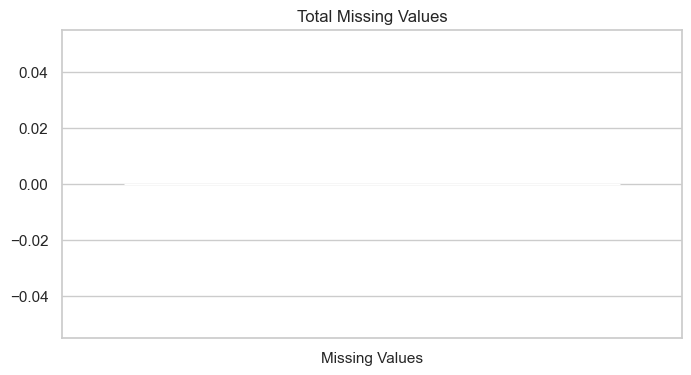

In [10]:
plt.figure(figsize=(8,4))

sns.barplot(
    x=["Missing Values"],
    y=[missing.sum()],
    color="steelblue"
)

plt.title("Total Missing Values")

plt.show()

### Observation

No missing values are present in the cleaned dataset.
The dataset is ready for exploratory analysis.

In [11]:
duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 0


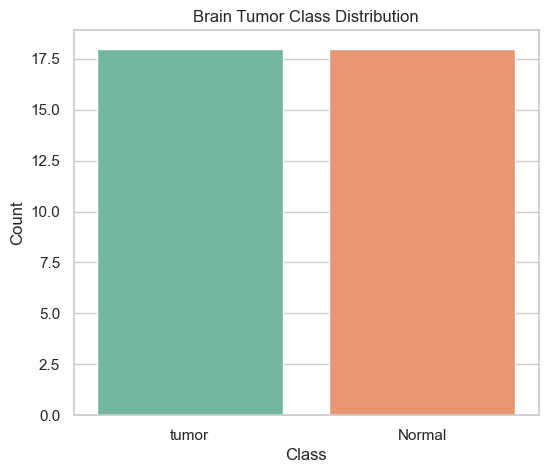

In [12]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="y",
    data=df,
    palette="Set2"
)

plt.title("Brain Tumor Class Distribution")

plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [13]:
df["y"].value_counts(normalize=True)*100

y
tumor     50.0
Normal    50.0
Name: proportion, dtype: float64

### Observation

The visualization shows the distribution of tumor and non-tumor samples.
This helps identify whether the dataset is balanced or imbalanced.

In [14]:
X = df.drop("y", axis=1)
y = df["y"]

In [15]:
X.describe().T.head()

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,36.0,17.500000,10.535654,0.0,8.75,17.5,26.25,35.0
X53416,36.0,378.750000,648.716067,-694.0,-95.75,194.5,721.75,1815.0
M83670,36.0,177.305556,243.494655,-117.0,-31.00,117.0,330.50,718.0
X90908,36.0,128.027778,787.935802,-50.0,-13.25,-4.5,14.00,4723.0
M97496,36.0,568.305556,637.451928,8.0,47.25,293.5,1079.25,2261.0


In [16]:
variance = X.var().sort_values(ascending=False)

top20 = variance.head(20)

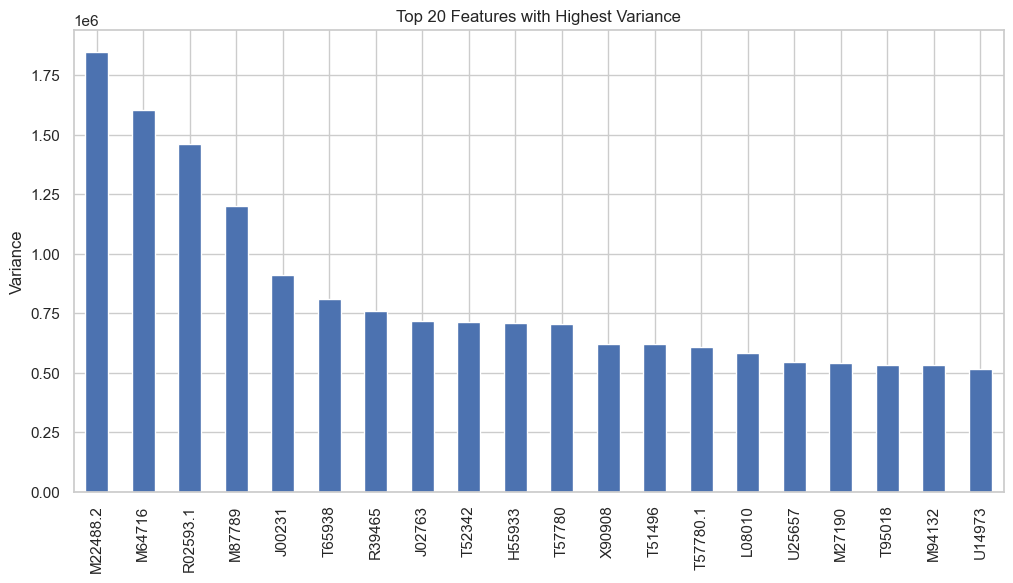

In [17]:
plt.figure(figsize=(12,6))

top20.plot(kind="bar")

plt.title("Top 20 Features with Highest Variance")

plt.ylabel("Variance")

plt.show()

### Observation

High variance features usually contain more information for distinguishing different classes.

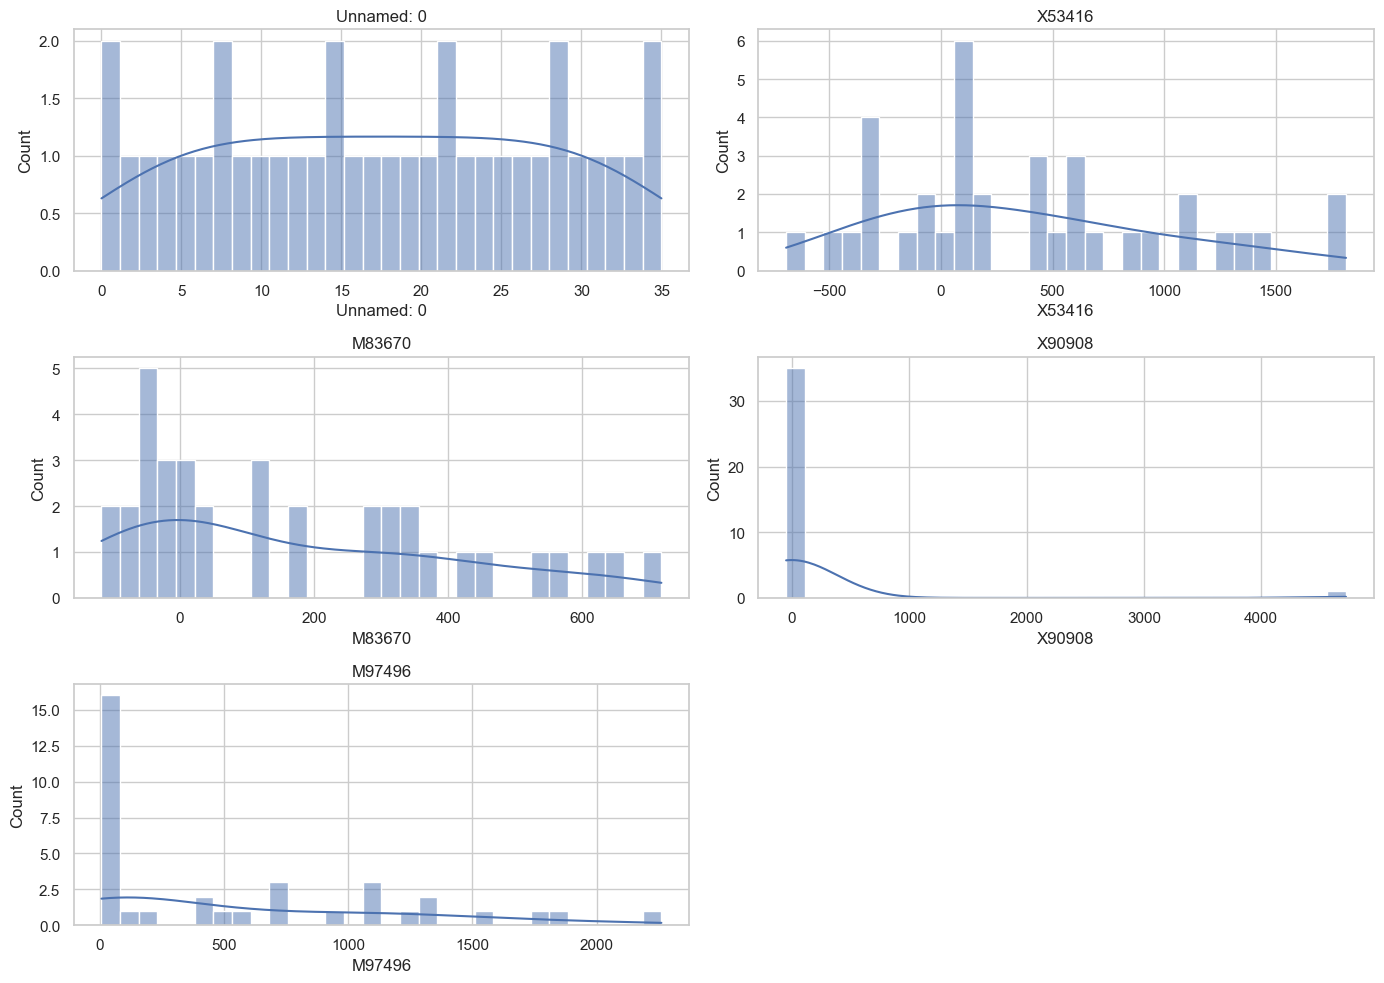

In [ ]:
sample_features = X.columns[:5]

plt.figure(figsize=(14,10))

for i, feature in enumerate(sample_features):

    plt.subplot(3,2,i+1)

    sns.histplot(
        X[feature],
        bins=30,
        kde=True
    )

    plt.title(feature)

plt.tight_layout()

plt.show()l

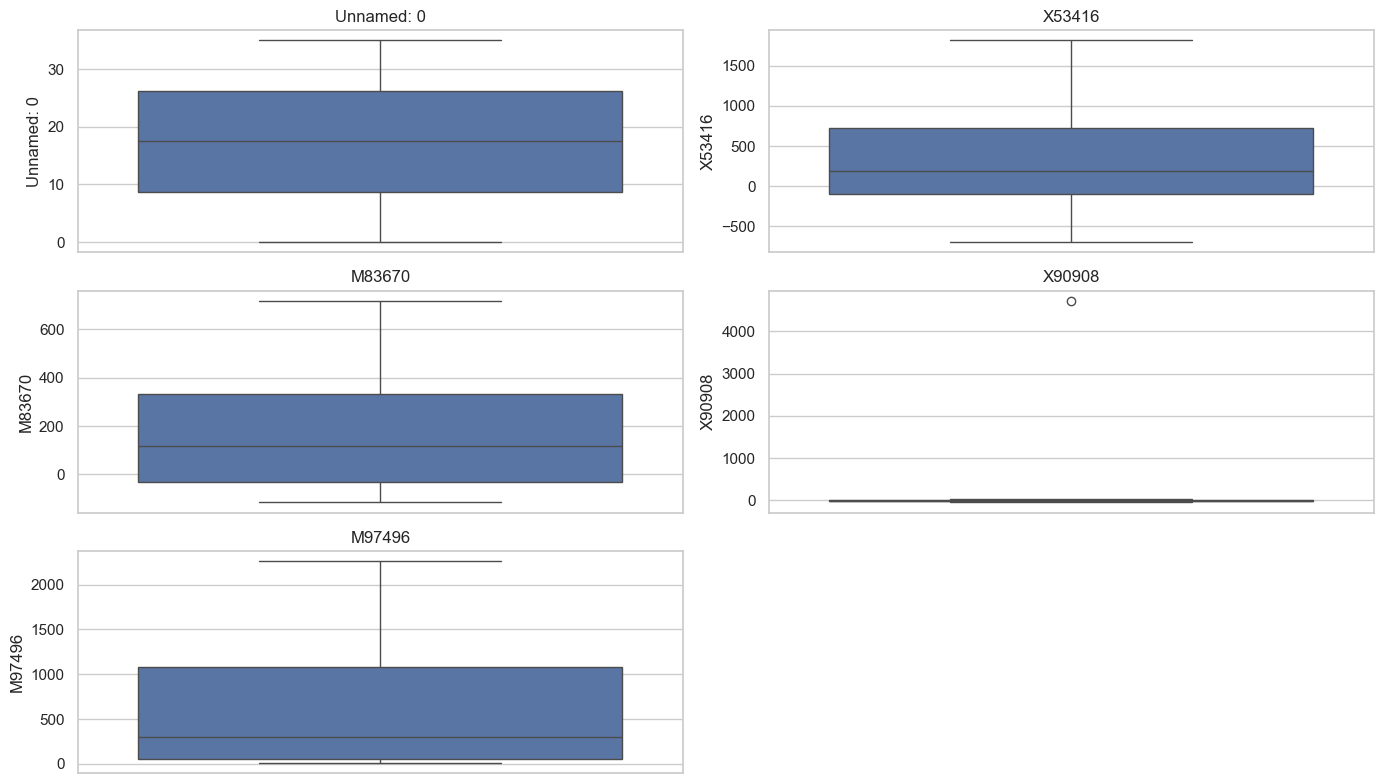

In [19]:
plt.figure(figsize=(14,8))

for i, feature in enumerate(sample_features):

    plt.subplot(3,2,i+1)

    sns.boxplot(
        y=X[feature]
    )

    plt.title(feature)

plt.tight_layout()

plt.show()

### Observation

Several features contain extreme values.
These may represent natural biological variation rather than errors.

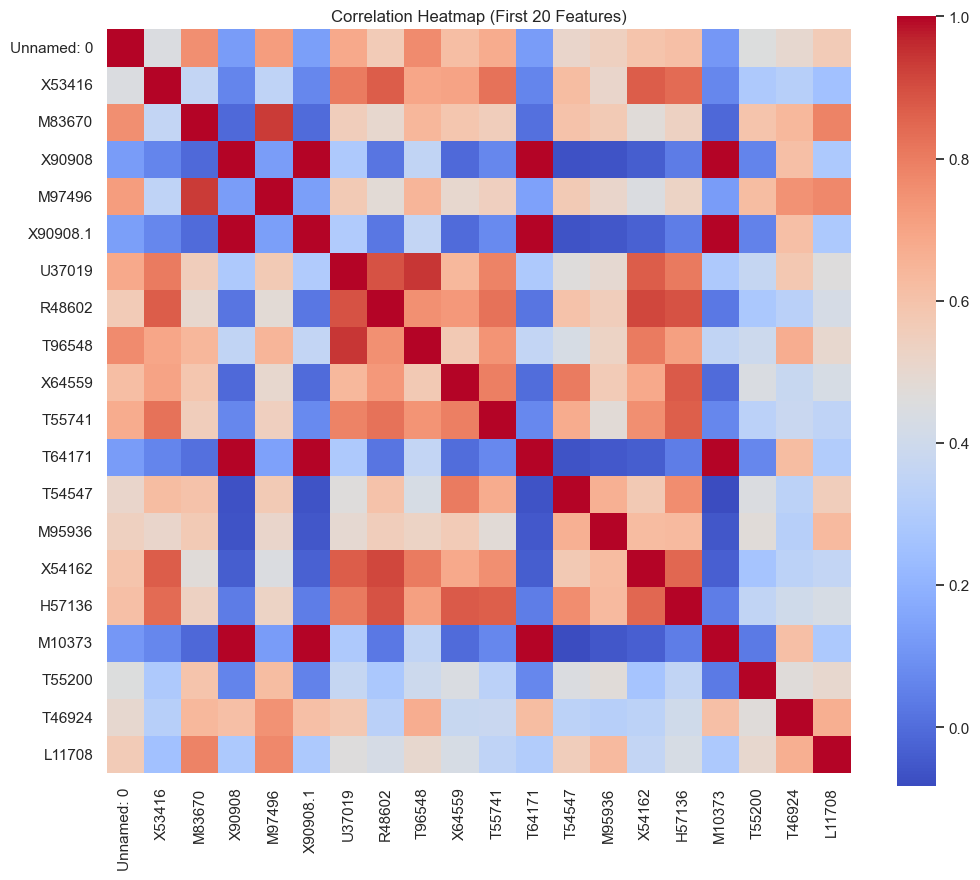

In [20]:
corr = X.iloc[:, :20].corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    square=True
)

plt.title("Correlation Heatmap (First 20 Features)")

plt.show()

### Observation

The heatmap shows relationships among a subset of gene expression features.
Strong positive and negative correlations indicate features that may behave similarly.

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "Class": y
})

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Separate features and target
X = df.drop("y", axis=1)
y = df["y"]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create DataFrame for visualization
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Class": y.values
})

# Display first few rows
pca_df.head()


,PC1,PC2,Class
0,33.472385,-20.197628,tumor
1,28.107253,-26.452239,tumor
2,33.209195,-18.931014,tumor
3,31.515963,-16.896834,tumor
4,27.139994,-24.048082,tumor


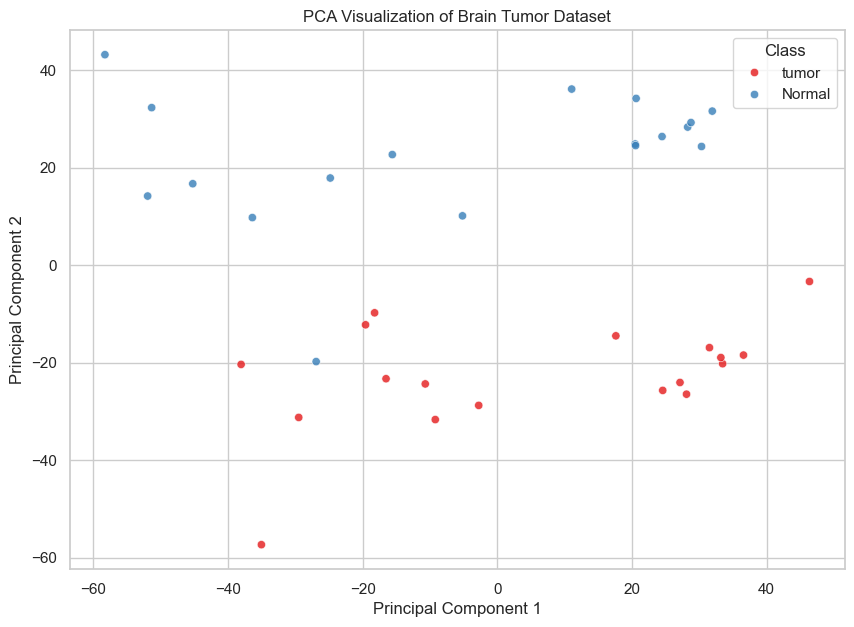

In [23]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Class",
    palette="Set1",
    alpha=0.8
)

plt.title("PCA Visualization of Brain Tumor Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [24]:
explained = pca.explained_variance_ratio_

print("PC1 :", explained[0])
print("PC2 :", explained[1])

PC1 : 0.12332073661603946
PC2 : 0.08899132372908518


In [25]:
summary = pd.DataFrame({
    "Mean": X.mean(),
    "Median": X.median(),
    "Std": X.std(),
    "Variance": X.var()
})

summary.head()

,Mean,Median,Std,Variance
Unnamed: 0,17.500000,17.5,10.535654,111.000000
X53416,378.750000,194.5,648.716067,420832.535714
M83670,177.305556,117.0,243.494655,59289.646825
X90908,128.027778,-4.5,787.935802,620842.827778
M97496,568.305556,293.5,637.451928,406344.961111


# Conclusion

## Key Findings

- The dataset is clean and contains no missing values.
- Duplicate records have been removed during preprocessing.
- The target variable shows the distribution of tumor classes.
- Several gene expression features exhibit high variance.
- Boxplots indicate the presence of biological outliers.
- PCA successfully reduces thousands of dimensions into two principal components for visualization.
- Correlation analysis reveals relationships among selected genes.

## Overall Conclusion

The dataset is well-prepared for machine learning. Exploratory Data Analysis confirms that the data quality is high and provides valuable insights into feature distributions, class balance, and dimensionality, making it suitable for predictive modeling.